In [288]:
# %pip install pandas pyarrow scikit-learn pymorphy3 joblib

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib

import re
from pymorphy3 import MorphAnalyzer
import emoji

from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# импортируем трансформеры
import transformers
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torchutils as tu
from torchmetrics.classification import BinaryAccuracy

/home/andre/Elbrus-DataScience/lessons/project_elb/nlp_lora/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [290]:
# Загрузка данных
df = pd.read_feather('data/tg_channels.feather')

print(df.head())

                               url                      date  \
0  https://t.me/s/russianmoda/5961 2023-09-17 17:09:06+00:00   
1  https://t.me/s/russianmoda/5957 2023-09-17 12:09:06+00:00   
2  https://t.me/s/russianmoda/5951 2023-09-17 06:09:06+00:00   
3  https://t.me/s/russianmoda/5939 2023-09-16 17:09:06+00:00   
4  https://t.me/s/russianmoda/5935 2023-09-16 12:09:06+00:00   

                                             content label  
0  Широкие бедра всегда считались роскошью и прид...  мода  
1  Не знаю как у вас, но у меня ни одна осень не ...  мода  
2  Осенью настроение немножко ухудшается. Этому с...  мода  
3  Кардиган очень коварен в стилизации, поэтому е...  мода  
4  Трикотажные костюмы часто ассоциируются с брюк...  мода  


In [291]:
df.head()

,url,date,content,label
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода


In [292]:
df.shape

(2900, 4)

In [293]:
df['label'].value_counts(normalize=True)

label
мода          0.206897
технологии    0.206897
финансы       0.206897
крипта        0.206897
спорт         0.172414
Name: proportion, dtype: float64

In [294]:
df.describe()

,url,date,content,label
count,2900,2900,2852,2900
unique,2900,NaN,2779,5
top,https://t.me/s/russianmoda/5961,NaN,"🤯 СКА проиграл ""Торпедо"" в матче КХЛВстреча за...",мода
freq,1,NaN,3,600
mean,NaN,2023-08-14 12:46:32.431379200+00:00,NaN,NaN
min,NaN,2022-11-21 15:46:54+00:00,NaN,NaN
25%,NaN,2023-07-28 15:07:17.249999872+00:00,NaN,NaN
50%,NaN,2023-09-02 12:25:26.500000+00:00,NaN,NaN
75%,NaN,2023-09-13 16:31:23.750000128+00:00,NaN,NaN
max,NaN,2023-09-17 20:17:38+00:00,NaN,NaN


In [295]:
df['content'][1000]

'Евгений Рылов не собирается прогибаться под требования МОК: олимпийский чемпион заявил, что откажется подписывать декларации для участия в ОИ."В МОК могут выдвинуть условия подписать декларацию, если мне такое предложат, я точно откажусь", - сказал пловец.Достойное решение 👏🏻'

In [296]:
morph = MorphAnalyzer()

def clean_text_v2(text):
    # 1. Удаляем ссылки (t.me, http, https)
    text = re.sub(r'https?://\S+|www\.\S+|t\.me/\S+', ' ', text)
    
    # 2. Удаляем ВСЁ, кроме букв (русских и английских) и пробелов
    # Это очистит эмодзи (👏🏻, 🏆), пунктуацию и цифры
    text = re.sub(r'[^а-яА-Я\s]', ' ', text)
    
    # 3. Приводим к нижнему регистру и убираем лишние пробелы
    text = text.lower().strip()
    
    # 4. Лемматизация (приведение к начальной форме)
    # Разбиваем текст на слова, лемматизируем и оставляем слова длиннее 2 символов
    tokens = [
        morph.parse(word)[0].normal_form 
        for word in text.split() 
        if len(word) > 2
    ]
    
    return " ".join(tokens)

# Проверка на вашем примере:
example = df['content'][100]
print(f"Результат очистки:\n{clean_text_v2(example)}")

Результат очистки:
один самый стильный образ пиджак можно созадть сочетать он платье комбинация комбинация считаться база гардероб помимо пиджак быть отлично смотреться рубашка или свитер


In [297]:
df.isna().mean()

url        0.000000
date       0.000000
content    0.016552
label      0.000000
dtype: float64

если контента нет, то эти строки не информативны так как невозможно на основании пустоты предсказать тему

In [298]:
df = df.dropna(subset=['content'])

In [299]:
df.isna().mean()

url        0.0
date       0.0
content    0.0
label      0.0
dtype: float64

### BaseLine на LogisticRegression

In [300]:
df['label'].value_counts(normalize=True)

label
мода          0.209677
технологии    0.206522
финансы       0.204418
крипта        0.204418
спорт         0.174965
Name: proportion, dtype: float64

In [301]:
print("Начинаю очистку датасета...")
df['cleaned_content'] = df['content'].apply(clean_text_v2)
print("Очистка завершена!")

Начинаю очистку датасета...
Очистка завершена!


In [302]:
print(df['content'][101])
print(df['cleaned_content'][101])

Сейчас актуальны и укороченные, и удлиненные модели пиджаков. Конечно же, помним и про классику. У брендов ниже представлены самые необычные варианты, из которых вы точно выберете свой идеальный пиджак!SHI SHISTUDIO 29Nude StoryLichi
сейчас актуальный укоротить удлинённый модель пиджак конечно помнить про классика бренд ниже представить самый необычный вариант который точно выбрать свой идеальный пиджак


In [303]:
mapping = {'мода': 0, 
           'технологии': 1, 
           'финансы': 2, 
           'крипта': 3, 
           'спорт': 4}
df['label_num'] = df['label'].map(mapping)

In [304]:
X_train, X_valid, y_train, y_valid = train_test_split(df['cleaned_content'], df['label_num'], test_size=0.25, random_state=42, stratify=df['label_num'])
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.35, random_state=42, stratify=y_valid)
print(f"Обучение (Train): {len(X_train)} строк")
print(f"Валидация (Val):   {len(X_valid)} строк")
print(f"Тест (Test):       {len(X_test)} строк")

Обучение (Train): 2139 строк
Валидация (Val):   463 строк
Тест (Test):       250 строк


In [305]:
from collections import Counter

# Собираем все слова из тренировочной выборки
all_words = ' '.join(X_train).split()
word_counts = Counter(all_words)

print(f"Всего уникальных слов: {len(word_counts)}")

# Смотрим, сколько слов встречаются хотя бы 2 или 3 раза
min_freq = 3
words_above_min = [w for w, c in word_counts.items() if c >= min_freq]
print(f"Слов с частотой >= {min_freq}: {len(words_above_min)}")

Всего уникальных слов: 15216
Слов с частотой >= 3: 5962


In [306]:
tfidf = TfidfVectorizer(max_features=5962, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

In [307]:
model_logreg = LogisticRegression(C=10, max_iter=1000, random_state=42)
model_logreg.fit(X_train_tfidf, y_train)

# Предсказываем на валидации
y_pred_val = model_logreg.predict(X_valid_tfidf)

# Смотрим результат
print(f"Accuracy на валидации: {accuracy_score(y_valid, y_pred_val):.4f}")
print("\nОтчет по классам:")
print(classification_report(y_valid, y_pred_val))

Accuracy на валидации: 0.9201

Отчет по классам:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        97
           1       0.83      0.94      0.88        95
           2       0.92      0.88      0.90        95
           3       0.98      0.89      0.93        95
           4       0.92      0.99      0.95        81

    accuracy                           0.92       463
   macro avg       0.92      0.92      0.92       463
weighted avg       0.92      0.92      0.92       463



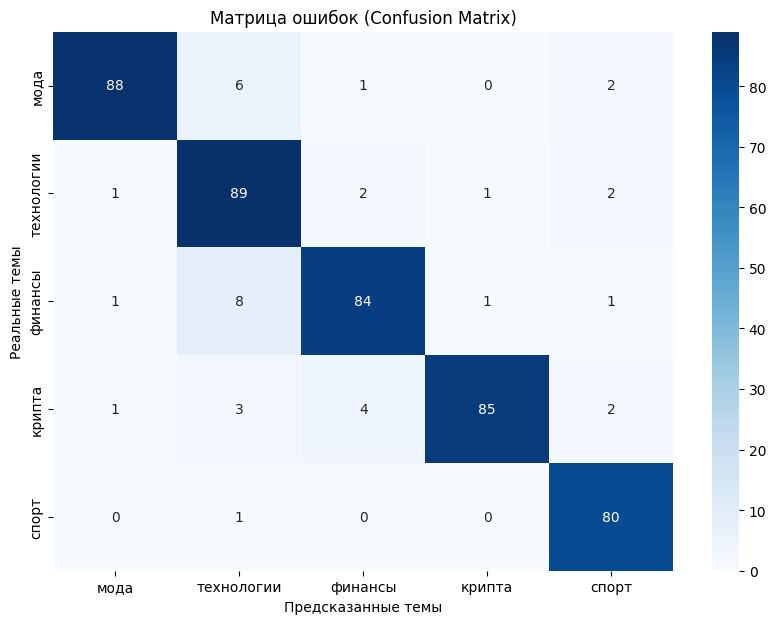

In [308]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_valid, y_pred_val)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [309]:
y_pred_test = model_logreg.predict(X_test_tfidf)

# Смотрим результат
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nОтчет по классам:")
print(classification_report(y_test, y_pred_test))

Accuracy на тесте: 0.9160

Отчет по классам:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93        52
           1       0.84      0.94      0.89        52
           2       0.92      0.90      0.91        51
           3       0.94      0.90      0.92        51
           4       0.91      0.95      0.93        44

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



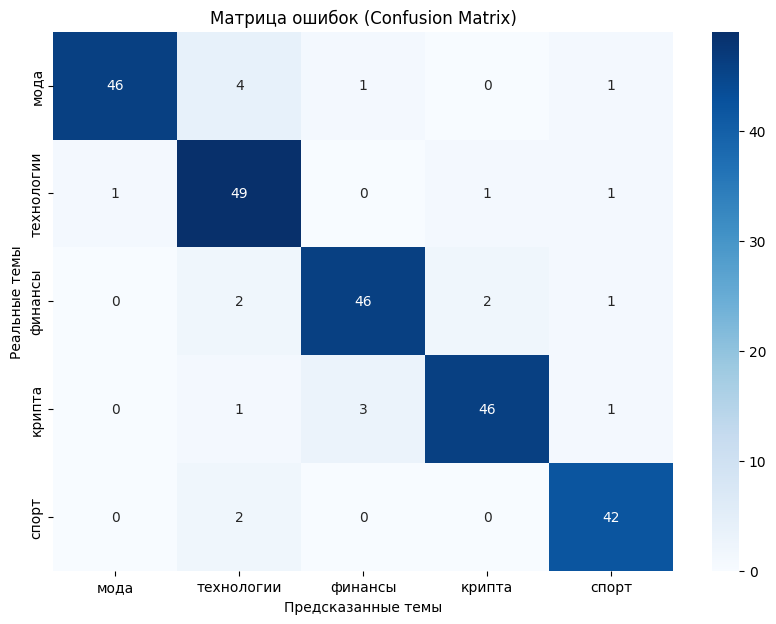

In [310]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_test)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [311]:
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
# rf.fit(X_train_tfidf, y_train)

In [312]:
# y_pred_valid_rf =rf.predict(X_valid_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_valid, y_pred_valid_rf):.4f}")

In [313]:
# y_pred_test_rf = rf.predict(X_test_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_test, y_pred_test_rf):.4f}")

Отличный показатель логистической регрессии на baseline